# Testes com a avaliação de amostras no QGIS

- Extensão de amostras como plugin do QGIS usando SOM como base;
- Para que o problema não fique apenas técnico e limitado a algumas técnicas específicas;
- Inserir a parte de classificação + avaliação no plugin após a seleção das amostras;

## Etapas:

 - Seleção de área e período;
 - Visualização da imagem (Busca de imagem via STAC);
 - Seleção de grade SOM e atributos;
 - Avaliação do agrupamento;
 - Definição da taxa de amostras por classe;
 - Extração das séries temporais;
 - Classificação multiclasse com MLP;

In [93]:
import numpy as np
import xarray as xr
from simplecube import simple_cube
import matplotlib.pyplot as plt
from som import SOMNetwork
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

In [11]:
stac_url = "https://data.inpe.br/bdc/stac/v1"

In [57]:
S2_cube=simple_cube(
    stac_url=stac_url,
    collection="S2-16D-2",
    start_date="2025-08-01",
    end_date="2025-08-30",
    bbox="-45.8323,-12.9385,-45.7727,-12.8817",
    bands=["B02","B03","B04"]
)

S2_cube

Fetching... : 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 78.18 scenes/s]
/home/labgeo10/plugins/ACRP_trabalho_final/simplecube.py:674: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  data_cube = xr.merge([data_cube, band_data_array])
/home/labgeo10/plugins/ACRP_trabalho_final/simplecube.py:674: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new d

<xarray.Dataset> Size: 8MB
Dimensions:      (time: 3, band: 1, y: 658, x: 657)
Coordinates:
  * time         (time) datetime64[us] 24B 2025-07-28 2025-08-13 2025-08-29
  * band         (band) int64 8B 1
  * y            (y) float64 5kB 9.888e+06 9.888e+06 ... 9.882e+06 9.882e+06
  * x            (x) float64 5kB 5.873e+06 5.873e+06 ... 5.879e+06 5.879e+06
    spatial_ref  int64 8B 0
Data variables:
    blue         (time, band, y, x) int16 3MB 722 719 688 708 ... 1268 1249 1285
    green        (time, band, y, x) int16 3MB 1093 1067 1055 ... 1692 1679 1702
    red          (time, band, y, x) int16 3MB 1714 1681 1678 ... 2136 2070 2170

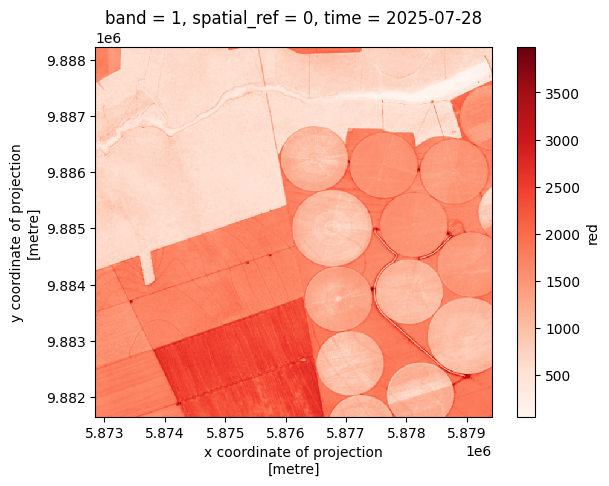

In [58]:
S2_cube["red"].isel(time=0, band=0).plot(cmap="Reds")

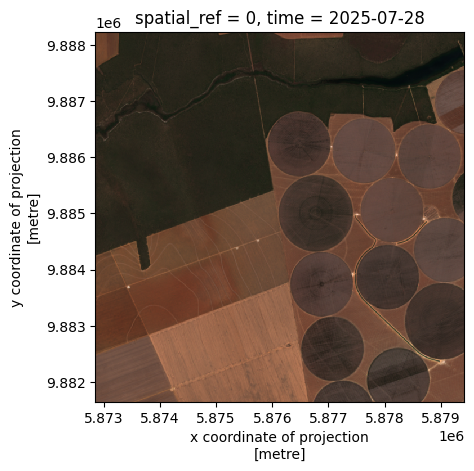

In [59]:
rgb = xr.concat([
    S2_cube["red"].isel(time=0, band=0),
    S2_cube["green"].isel(time=0, band=0),
    S2_cube["blue"].isel(time=0, band=0)  # substituindo blue
], dim="band")

rgb = rgb.assign_coords(band=["R", "G", "B"])
rgb = rgb.transpose("y", "x", "band")

rgb = rgb / rgb.max()
rgb.plot.imshow()
plt.gca().set_aspect('equal')

xarray => numpy (pixels × bandas)

normaliza

treina SOM

encontra BMU (Best Matching Unit)

reshape => imagem

In [60]:
# selecionar um tempo e remover band
red = S2_cube["red"].isel(time=0, band=0)
green = S2_cube["green"].isel(time=0, band=0)
blue = S2_cube["blue"].isel(time=0, band=0)

# stack das bandas → (y, x, features)
stacked = xr.concat([red, green, blue], dim="feature")
stacked = stacked.transpose("y", "x", "feature")

# transformar em (n_pixels, n_features)
X = stacked.values.reshape(-1, 3)

In [61]:
norms = np.linalg.norm(X, axis=1, keepdims=True)
X = X / (norms + 1e-8)

In [62]:
som = SOMNetwork(grid_dimensions=(10, 10), input_dimension=3)

def gaussian_neighbor(xw, yw, x, y, sigma):
    return np.exp(-((x-xw)**2 + (y-yw)**2) / (2*sigma**2))

idx = np.random.choice(len(X), size=50000, replace=False)
X_sample = X[idx]

# treinamento
for epoch in range(5):
    for x in X_sample:
        som.organize(x.reshape(-1,1), eta=0.1, neighbor_fcn=gaussian_neighbor, sigma=2)

image shape:  (10, 10, 3)


Text(0.5, 1.0, 'Trained neural network grid representation')

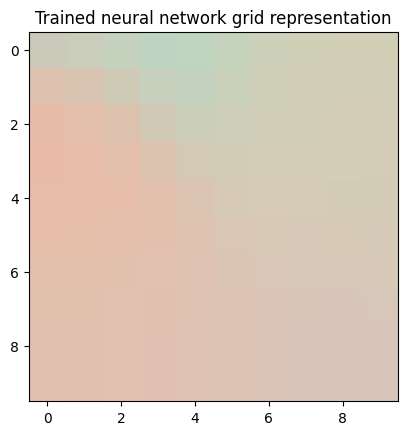

In [70]:
nnet_img_repr_trained = np.zeros((som.grid_dimensions[0], som.grid_dimensions[1], 3), dtype=np.uint8)
print("image shape: ", nnet_img_repr_trained.shape)
#lets convert weight representation to RGB values:
# We must identify the

RGBMAX = 255
for i in range(som.grid_dimensions[0]):
    for j in range(som.grid_dimensions[1]):
        #w_norm = np.linalg.norm(my_som_net.neurons[i, j].weights)
        #w_normalized = my_som_net.neurons[i, j].weights/w_norm
        #weight = w_normalized.flatten() #my_som_net.neurons[i, j].weights.flatten()
        weight = som.neurons[i, j].weights.flatten()
        nnet_img_repr_trained[i,j][:] = ((RGBMAX / 2) * (weight + 1)).astype(int)

plt.figure()
plt.imshow(nnet_img_repr_trained)
plt.title("Trained neural network grid representation")

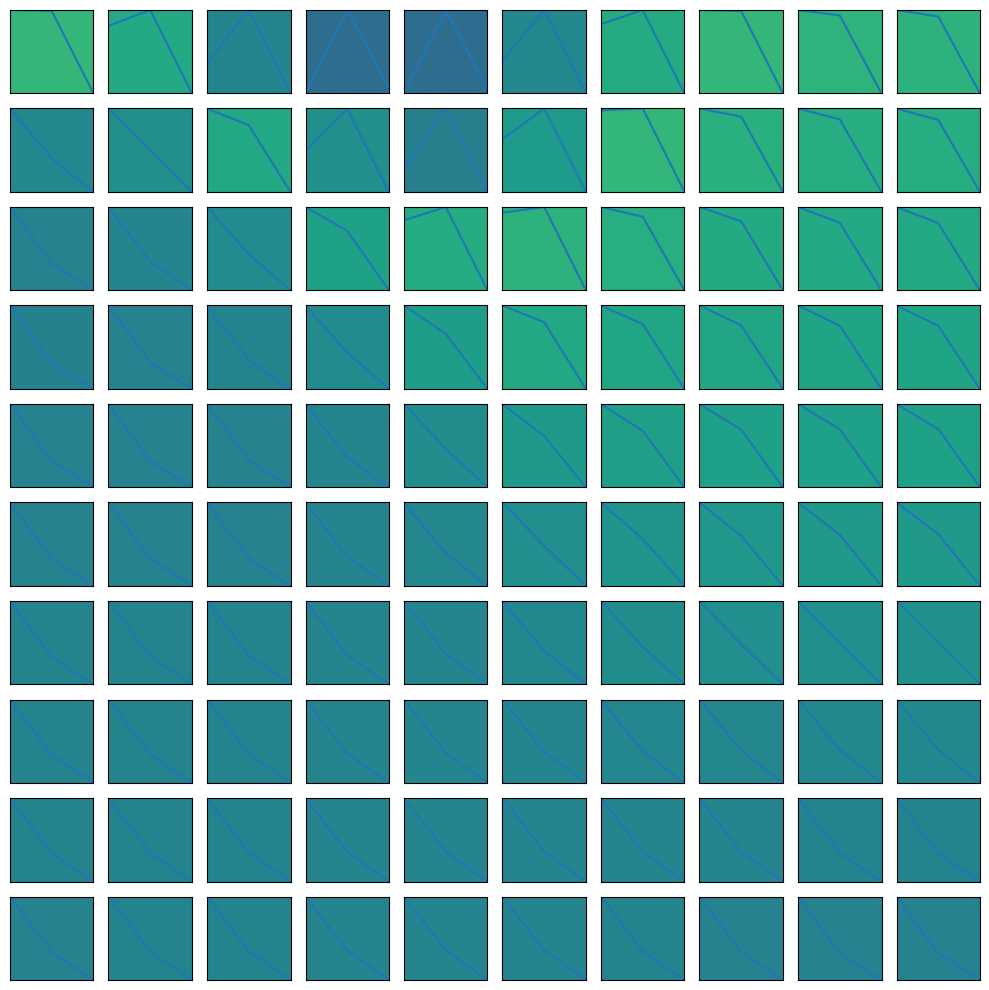

In [84]:
import matplotlib.pyplot as plt
import numpy as np

def plot_som_neurons(som):
    rows, cols = som.grid_dimensions
    
    fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
    
    for i in range(rows):
        for j in range(cols):
            ax = axes[i, j]
            
            # pegar pesos do neurônio
            w = som.neurons[i, j].weights.flatten()

            w = (w - w.min()) / (w.max() - w.min() + 1e-8)
            mean_val = w.mean()
            color = plt.cm.viridis(mean_val)
            ax.set_facecolor(color)
            
            # deixar visual limpo
            ax.set_xticks([])
            ax.set_yticks([])
            
            # opcional: limites fixos (melhora comparação)
            ax.plot(np.linspace(0,1,len(w)), w)
            ax.set_xlim(0,1)
            ax.set_ylim(0,1)
    
    plt.tight_layout()
    plt.show()

plot_som_neurons(som)

In [63]:
labels = []

for x in X:
    activations = np.zeros(som.grid_dimensions)
    
    for i in range(som.grid_dimensions[0]):
        for j in range(som.grid_dimensions[1]):
            activations[i,j] = np.dot(
                x.flatten(),
                som.neurons[i,j].weights.flatten()
            )
    
    winner = np.argmax(activations)
    labels.append(winner)

labels = np.array(labels)

In [64]:
cluster_map = labels.reshape(stacked.shape[0], stacked.shape[1])

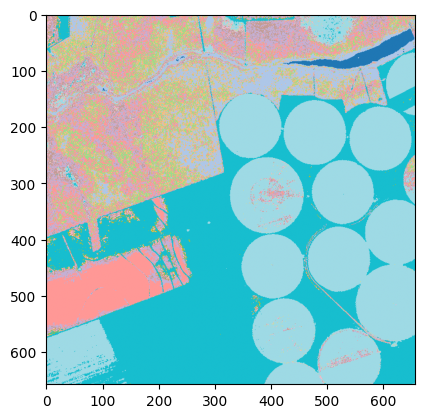

In [65]:
plt.imshow(cluster_map, cmap="tab20")

## Descobrindo as classes:

### K-means:

In [85]:
from sklearn.cluster import KMeans
import numpy as np

# extrair pesos
weights = []
for i in range(som.grid_dimensions[0]):
    for j in range(som.grid_dimensions[1]):
        weights.append(som.neurons[i,j].weights.flatten())

weights = np.array(weights)

# clusterizar neurônios
kmeans = KMeans(n_clusters=5)
labels = kmeans.fit_predict(weights)

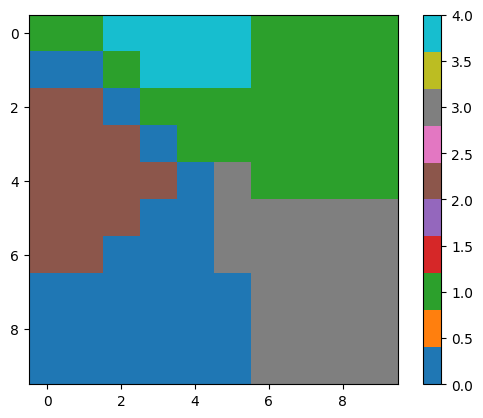

In [87]:
label_map = labels.reshape(som.grid_dimensions)
import matplotlib.pyplot as plt
plt.imshow(label_map, cmap="tab10")
plt.colorbar()

### Agrupamento hierarquico

In [88]:
weights = []
positions = []

for i in range(som.grid_dimensions[0]):
    for j in range(som.grid_dimensions[1]):
        weights.append(som.neurons[i,j].weights.flatten())
        positions.append((i, j))

weights = np.array(weights)

Text(0.5, 1.0, 'Dendrograma dos neurônios')

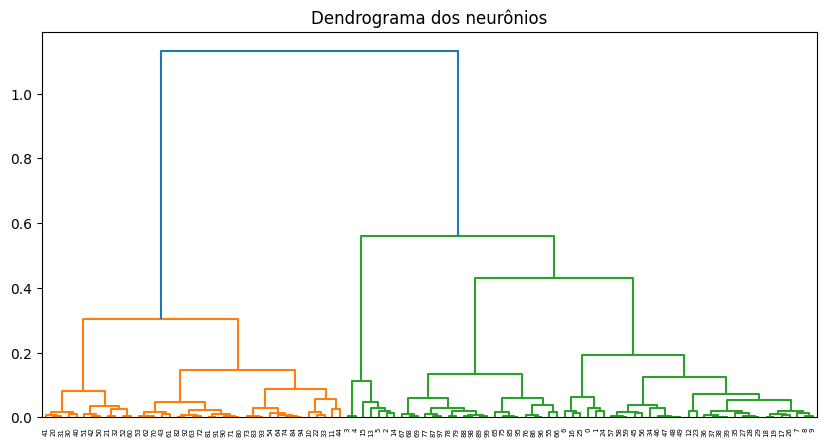

In [94]:
# Não precisa escolher clusters exatos de início
# Permite explorar níveis (2, 3, 5, 10 classes…)
# Funciona muito bem com poucos neurônios

# linkage: 'ward' funciona muito bem
Z = linkage(weights, method='ward')

# escolher número de classes
n_classes = 5
labels = fcluster(Z, n_classes, criterion='maxclust')
plt.figure(figsize=(10,5))
dendrogram(Z)
plt.title("Dendrograma dos neurônios")

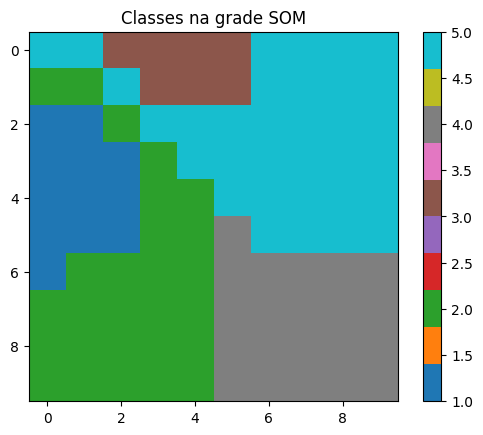

In [95]:
label_map = np.zeros(som.grid_dimensions)

for (i, j), label in zip(positions, labels):
    label_map[i, j] = label


plt.imshow(label_map, cmap="tab10")
plt.title("Classes na grade SOM")
plt.colorbar()
plt.show()

In [97]:
label_map = np.zeros(som.grid_dimensions)

for (i, j), label in zip(positions, labels):
    label_map[i, j] = label

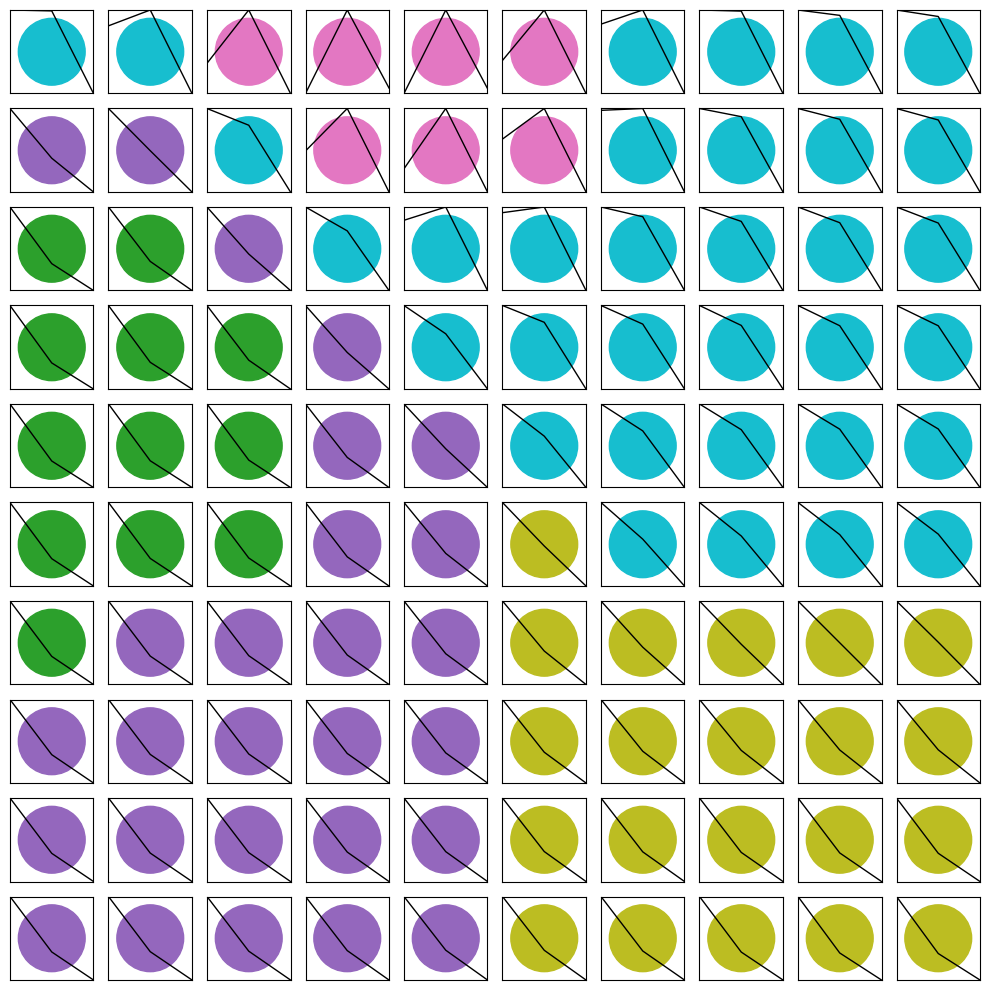

In [99]:

def plot_som_neurons(som, labels):
    rows, cols = som.grid_dimensions
    label_map = labels.reshape(rows, cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
    
    for i in range(rows):
        for j in range(cols):
            ax = axes[i, j]
            
            # pegar label
            label = int(label_map[i, j])
            color = plt.cm.tab10(label / np.max(label_map))
            
            # desenhar círculo
            circle = plt.Circle((0.5, 0.5), 0.4, color=color)
            ax.add_patch(circle)
            
            # opcional: pesos (assinatura espectral)
            w = som.neurons[i, j].weights.flatten()
            w = (w - w.min()) / (w.max() - w.min() + 1e-8)
            
            ax.plot(np.linspace(0,1,len(w)), w, color="black", linewidth=1)
            
            # estética
            ax.set_xlim(0,1)
            ax.set_ylim(0,1)
            ax.set_xticks([])
            ax.set_yticks([])
    
    plt.tight_layout()
    plt.show()

plot_som_neurons(som, label_map)

SOM organiza padrões no espaço

Hierárquico corta esse espaço em regiões

BMU leva isso para a imagem

Resumo

Com hierárquico você:

agrupa neurônios
define classes na grade

In [91]:
pixel_classes = []

for x in X:
    activations = np.zeros(som.grid_dimensions)

    for i in range(som.grid_dimensions[0]):
        for j in range(som.grid_dimensions[1]):
            activations[i,j] = np.dot(
                x.flatten(),
                som.neurons[i,j].weights.flatten()
            )

    winner = np.argmax(activations)
    pixel_classes.append(labels[winner])

pixel_classes = np.array(pixel_classes)

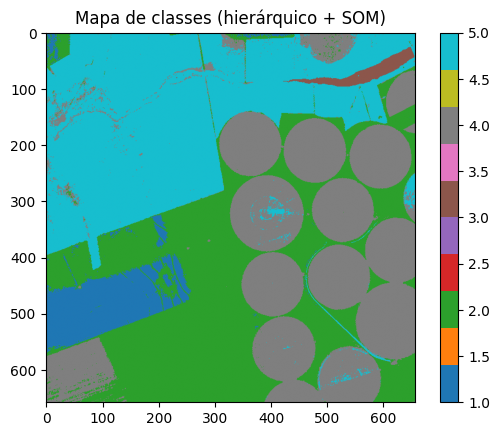

In [100]:
height, width = stacked.shape[0], stacked.shape[1]

cluster_map = pixel_classes.reshape(height, width)

plt.imshow(cluster_map, cmap="tab10")
plt.title("Mapa de classes (hierárquico + SOM)")
plt.colorbar()

### Transformar em polígonos

In [126]:
import xarray as xr
import rioxarray
import rasterio
from rasterio.features import shapes
import geopandas as gpd
from shapely.geometry import shape


cluster_da = xr.DataArray(
    cluster_map,
    dims=("y", "x"),
    coords={
        "y": S2_cube["y"],
        "x": S2_cube["x"]
    }
)

cluster_da = cluster_da.rio.write_crs(S2_cube.rio.crs)

In [132]:
transform = cluster_da.rio.transform()

shapes_gen = shapes(
    cluster_da.values.astype("int32"),
    transform=transform
)

shapes_gen

<generator object shapes at 0x709ba7342a70>

In [133]:
geoms = []
vals = []

for geom, value in shapes_gen:
    geoms.append(shape(geom))
    vals.append(value)

gdf = gpd.GeoDataFrame(
    {"class": vals},
    geometry=geoms,
    crs=cluster_da.rio.crs
)

# Próximo passo recomendado
gdf = gdf.dissolve(by="class")

gdf = gdf.reset_index()
gdf

,class,geometry
0,1.0,"MULTIPOLYGON (((5872900 9882510, 5872900 98825..."
1,2.0,"MULTIPOLYGON (((5873070 9881660, 5873070 98816..."
2,3.0,"MULTIPOLYGON (((5873890 9886870, 5873880 98868..."
3,4.0,"MULTIPOLYGON (((5872980 9881800, 5872960 98818..."
4,5.0,"MULTIPOLYGON (((5873590 9884630, 5873600 98846..."


In [136]:
gdf.to_file("clusters.shp")

<Axes: >

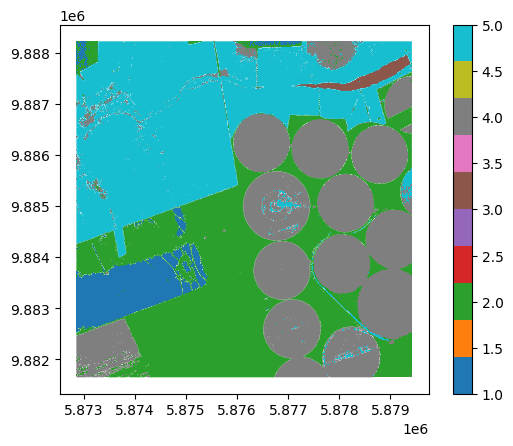

In [135]:
gdf.plot(column="class", cmap="tab10", legend=True)